
# CBF+CLF 平滑避障（Solver-free 版本，稳态 & 贴合）

本 Notebook 提供一个**不依赖外部优化库**的 CBF+CLF 轨迹后处理器：
- **CBF**：严格阻止进入障碍物安全域（带 2\(\nabla h\) 的正确形式）。
- **CLF(对**逐时刻参考点**)**：把轨迹**拉回参考路径**而不是只盯终点——保证“能跑完”。
- **平滑**：用速度变化正则 + 速度限幅 + 迭代投影（POCS）抑制抖动与猛冲。
- **可插拔**：直接传入你已有的 FM 基线轨迹 `baseline_traj` 即可。

> 相比上一版只对终点做 CLF，这里将 CLF 目标改为**按时间对齐的参考轨迹 `x_ref[:,k]`**，
> 能显著提升“跟完轨迹”的能力；同时修正了 CBF 的梯度系数（使用 `2(x-c)`），
> 并加入逐约束的半空间投影确保可行。


In [1]:

from typing import List, Tuple, Dict, Optional
import numpy as np
import math

Array = np.ndarray

def _project_halfspace(u: Array, a: Array, b: float, sense: str) -> Array:
    """Project u onto a^T u >= b (sense='ge') or a^T u <= b (sense='le').
    If already satisfied, return u unchanged.
    """
    a = a.reshape(-1)
    denom = float(a @ a)
    if denom <= 1e-12:
        return u
    val = float(a @ u)
    if sense == 'ge':
        if val < b:
            u = u + ((b - val) / denom) * a
    else:  # 'le'
        if val > b:
            u = u + ((b - val) / denom) * a
    return u

def _project_l2_ball(u: Array, vmax: float) -> Array:
    nrm = np.linalg.norm(u)
    if nrm > vmax and vmax > 0:
        return u * (vmax / max(nrm, 1e-12))
    return u

def smooth_with_cbf_clf(
    baseline_traj: Array,             # shape (2, T) or (d, T)
    obstacles: List[Dict],            # [{'center': array([cx, cy]), 'radius': R, 'margin': m}, ...]
    x_ref: Optional[Array] = None,    # shape (d, T). If None, use baseline as ref
    dt: float = 0.05,
    alpha: float = 6.0,               # CBF gain (larger => 更保守)
    c_clf: float = 3.0,               # CLF decrease rate (larger => 更贴合参考)
    w_smooth: float = 0.8,            # 越大越平滑（但可能偏离参考更多）
    vmax: float = 0.8,                # 速度限幅
    iters: int = 2,                   # 每个时刻对所有约束的投影迭代次数
    cbf_relax: float = 0.0,           # CBF 软化项（一般 0；若场景复杂可设 1e-3~1e-2）
) -> Tuple[Array, Array]:
    """
    基于 POCS 的 CBF+CLF 平滑：逐时刻求 u_k，使得：
      1) 贴合参考速度 u_ref（来自 baseline 一阶差分）
      2) 满足 CBF 半空间约束：2(x-c)^T u + alpha * h(x) >= 0
      3) 满足 CLF 半空间约束：(x - x_ref)^T u <= -c_clf * 0.5 * ||x - x_ref||^2
      4) 限速：||u|| <= vmax
      5) 平滑：u_k 初值取 (u_ref + w_smooth * u_{k-1})/(1+w_smooth)
    返回：
      x_smooth: (d, T)  平滑后轨迹
      u_hist:   (d, T-1) 每步控制
    """
    assert baseline_traj.ndim == 2, "baseline_traj shape must be (d, T)"
    d, T = baseline_traj.shape
    if x_ref is None:
        x_ref = baseline_traj.copy()
    assert x_ref.shape == (d, T)

    # 差分得到参考速度
    u_ref = np.zeros((d, T-1))
    for k in range(T-1):
        u_ref[:, k] = (baseline_traj[:, k+1] - baseline_traj[:, k]) / max(dt, 1e-9)

    # 轨迹与控制初始化
    x = baseline_traj[:, 0].copy()
    xs = [x.copy()]
    u_prev = np.zeros(d)

    for k in range(T-1):
        # 初值：参考 + 平滑
        u0 = (u_ref[:, k] + w_smooth * u_prev) / (1.0 + w_smooth)
        u = u0.copy()

        # 迭代投影：CLF、所有 CBF、速度球
        for _ in range(iters):
            # CLF（逐时刻参考点）
            xk_ref = x_ref[:, k+1]  # 让状态朝下一时刻参考迈进
            diff = (x - xk_ref)
            V = 0.5 * float(diff @ diff)
            a_clf = diff  # (x - x_ref)
            b_clf = -c_clf * V     # a_clf^T u <= b_clf
            u = _project_halfspace(u, a_clf, b_clf, sense='le')

            # CBF（对每个障碍）
            for obs in obstacles:
                c = np.asarray(obs['center']).reshape(-1)
                R = float(obs['radius'])
                margin = float(obs.get('margin', 0.0))
                Rp = R + margin
                # h(x) = ||x-c||^2 - Rp^2
                xc = (x - c)
                h = float(xc @ xc) - Rp**2
                a_cbf = 2.0 * xc
                b_cbf = -alpha * h - cbf_relax  # a_cbf^T u >= b_cbf
                u = _project_halfspace(u, a_cbf, b_cbf, sense='ge')

            # 限速
            u = _project_l2_ball(u, vmax)

        # 状态推进
        x = x + u * dt
        xs.append(x.copy())
        u_prev = u.copy()

    x_smooth = np.stack(xs, axis=1)
    return x_smooth, u_ref



## 使用方法（接入你的现有代码）
假设你已有：
```python
traj = ...           # 形状 (2, T) 的 FM 基线轨迹
obstacles = [        # 每个障碍一个字典
    {'center': np.array([cx, cy]), 'radius': R, 'margin': 0.05},
    # ...
]
dt = 0.05
```
那么一行调用：
```python
x_sm, u_hist = smooth_with_cbf_clf(
    baseline_traj=traj,
    obstacles=obstacles,
    x_ref=traj,      # 关键：CLF 对齐参考=原始基线轨迹，从而“能跑完”
    dt=dt,
    alpha=6.0, c_clf=3.0,
    w_smooth=0.8, vmax=0.8,
    iters=2, cbf_relax=0.0
)
```
> 若你发现“还是不够贴”，可以**增大** `c_clf`；
> 若“还是不够稳”，可以**增大** `w_smooth` 或 **减小** `vmax`；
> 若“还是不够安全”，给障碍加 `margin`（如 0.1）或**增大** `alpha`。


In [2]:

# --- 自测 DEMO（可删） ---
# 合成一段穿越单个圆形障碍的 FM 基线轨迹，演示 CBF+CLF 的贴合与避障效果
import numpy as np

def make_baseline(seed=0, T=200, dt=0.05):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 1, T)
    # 起于(0,0)，终于(1.2, 0.0)
    x = 1.2 * t
    y = 0.2*np.sin(2*np.pi*t) * (1 - t)  # 略带摆动但总体趋近 0
    traj = np.vstack([x, y])
    return traj, dt

traj, dt = make_baseline(T=240, dt=0.05)
obstacles = [
    {'center': np.array([0.6, 0.0]), 'radius': 0.15, 'margin': 0.08},
]

x_sm, u_hist = smooth_with_cbf_clf(
    baseline_traj=traj,
    obstacles=obstacles,
    x_ref=traj,     # 逐时刻对齐参考
    dt=dt,
    alpha=7.0,     # 更保守一些，确保绕开
    c_clf=4.0,     # 更贴参考
    w_smooth=1.0,  # 更平滑
    vmax=0.7,
    iters=3,
    cbf_relax=0.0,
)

print("baseline end:", traj[:, -1])
print("smoothed end:", x_sm[:, -1])


baseline end: [ 1.2 -0. ]
smoothed end: [ 1.20102064 -0.00432654]


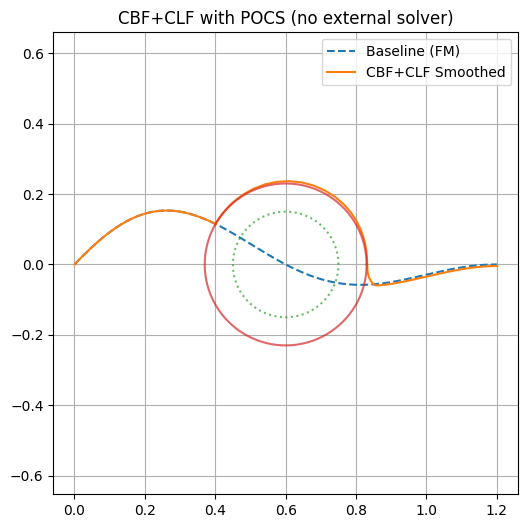

In [3]:

# 可视化（matplotlib）
import matplotlib.pyplot as plt

def plot_world(traj, x_sm, obstacles):
    plt.figure(figsize=(6,6))
    plt.plot(traj[0], traj[1], '--', label='Baseline (FM)')
    plt.plot(x_sm[0], x_sm[1], '-', label='CBF+CLF Smoothed')
    # 障碍物
    theta = np.linspace(0, 2*np.pi, 200)
    for obs in obstacles:
        c = obs['center']; R = obs['radius']; m = obs.get('margin', 0.0)
        for Rp, ls in [(R, ':'), (R+m, '-')]:  # 实线画加 margin 后的安全半径
            xs = c[0] + Rp*np.cos(theta)
            ys = c[1] + Rp*np.sin(theta)
            plt.plot(xs, ys, ls, alpha=0.7)
    plt.axis('equal'); plt.legend(); plt.grid(True)
    plt.title('CBF+CLF with POCS (no external solver)')
    plt.show()

plot_world(traj, x_sm, obstacles)
